# Supervised Learning

This notebook trains and evaluates supervised machine learning models
for network intrusion detection using the preprocessed NSL-KDD dataset.

## Models
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. SVM
5. XGBoost

Task 1 - Logistic Regression

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
X_train_processed = np.load("../data/processed/X_train_processed.npy")
X_val_processed = np.load("../data/processed/X_val_processed.npy")

y_binary_train = np.load("../data/processed/y_binary_train.npy")
y_binary_val = np.load("../data/processed/y_binary_val.npy")

y_multiclass_train = np.load("../data/processed/y_multiclass_train.npy", allow_pickle=True)
y_multiclass_val = np.load("../data/processed/y_multiclass_val.npy", allow_pickle=True)

print("Processed data loaded.")

Processed data loaded.


In [3]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_binary_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [4]:
y_binary_pred = logistic_model.predict(X_val_processed)
y_binary_prob = logistic_model.predict_proba(X_val_processed)[:, 1]

In [5]:
accuracy = accuracy_score(y_binary_val, y_binary_pred)
precision = precision_score(y_binary_val, y_binary_pred)
recall = recall_score(y_binary_val, y_binary_pred)
f1 = f1_score(y_binary_val, y_binary_pred)

print("Logistic Regression — Binary Classification")
print("--------------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_binary_val,
    y_binary_pred,
    target_names=["Normal", "Attack"]
))

print("Confusion Matrix:")
print(confusion_matrix(y_binary_val, y_binary_pred))

Logistic Regression — Binary Classification
--------------------------------------------
Accuracy : 0.9762
Precision: 0.9798
Recall   : 0.9688
F1 Score : 0.9743

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.98      0.98     13469
      Attack       0.98      0.97      0.97     11726

    accuracy                           0.98     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       0.98      0.98      0.98     25195

Confusion Matrix:
[[13235   234]
 [  366 11360]]


In [6]:
logistic_multiclass = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_multiclass.fit(
    X_train_processed,
    y_multiclass_train
)

y_multiclass_pred = logistic_multiclass.predict(X_val_processed)

print("Logistic Regression — Multiclass Classification")
print("------------------------------------------------")
print(classification_report(
    y_multiclass_val,
    y_multiclass_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_multiclass_val,
    y_multiclass_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"]
))

Logistic Regression — Multiclass Classification
------------------------------------------------
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13469
         DoS       1.00      1.00      1.00      9186
       Probe       0.99      0.98      0.98      2331
         R2L       0.76      0.73      0.74       199
         U2R       0.71      0.50      0.59        10

    accuracy                           0.99     25195
   macro avg       0.89      0.84      0.86     25195
weighted avg       0.99      0.99      0.99     25195

Confusion Matrix:
[[13374    20    30    43     2]
 [    8  9176     2     0     0]
 [   39     6  2284     2     0]
 [   51     0     2   146     0]
 [    3     0     0     2     5]]


In [7]:
logistic_results = {
    "Model": "Logistic Regression",
    "Binary Accuracy": accuracy,
    "Binary Precision": precision,
    "Binary Recall": recall,
    "Binary F1": f1,
    "Multiclass Accuracy": accuracy_score(y_multiclass_val, y_multiclass_pred),
    "Multiclass Macro F1": f1_score(
        y_multiclass_val,
        y_multiclass_pred,
        average="macro"
    ),
    "Multiclass Weighted F1": f1_score(
        y_multiclass_val,
        y_multiclass_pred,
        average="weighted"
    )
}

print(logistic_results)

{'Model': 'Logistic Regression', 'Binary Accuracy': 0.9761857511410994, 'Binary Precision': 0.979817146800069, 'Binary Recall': 0.9687873102507248, 'Binary F1': 0.9742710120068611, 'Multiclass Accuracy': 0.9916650128993848, 'Multiclass Macro F1': 0.861295601240276, 'Multiclass Weighted F1': 0.9916071157803651}


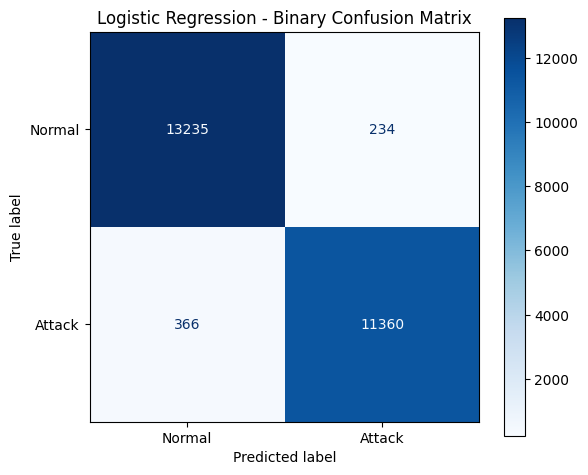

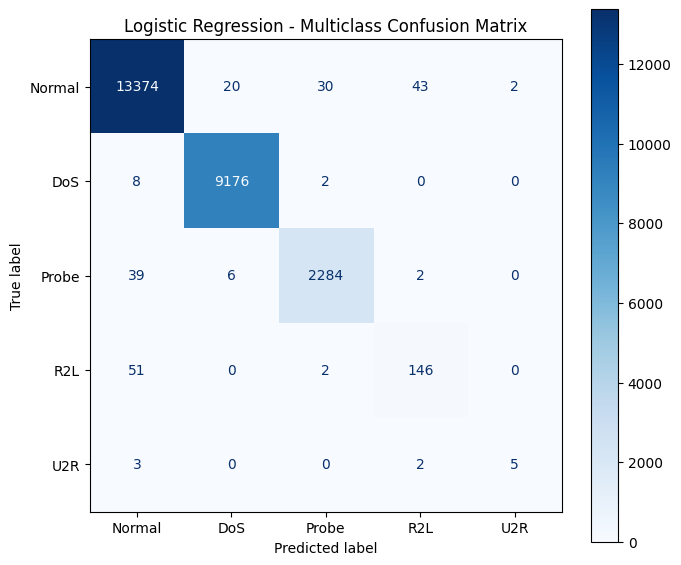

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# -------------------------------
# Binary Confusion Matrix
# -------------------------------
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_binary_val,
    y_binary_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Logistic Regression - Binary Confusion Matrix")
plt.tight_layout()
plt.show()


# -------------------------------
# Multiclass Confusion Matrix
# -------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_multiclass_val,
    y_multiclass_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    display_labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Logistic Regression - Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

Task 2 — Decision Tree

In [9]:
from sklearn.tree import DecisionTreeClassifier

# Binary
decision_tree_binary = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

decision_tree_binary.fit(
    X_train_processed,
    y_binary_train
)

# Multiclass
decision_tree_multiclass = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

decision_tree_multiclass.fit(
    X_train_processed,
    y_multiclass_train
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [10]:
y_binary_dt_pred = decision_tree_binary.predict(X_val_processed)
y_multiclass_dt_pred = decision_tree_multiclass.predict(X_val_processed)

In [11]:
print("DECISION TREE — BINARY")
print("----------------------")

print(classification_report(
    y_binary_val,
    y_binary_dt_pred,
    target_names=["Normal", "Attack"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(y_binary_val, y_binary_dt_pred))


print("\n\nDECISION TREE — MULTICLASS")
print("--------------------------")

print(classification_report(
    y_multiclass_val,
    y_multiclass_dt_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    zero_division=0
))

print("Confusion Matrix:")
print(confusion_matrix(
    y_multiclass_val,
    y_multiclass_dt_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"]
))

DECISION TREE — BINARY
----------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix:
[[13444    25]
 [   14 11712]]


DECISION TREE — MULTICLASS
--------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.96      0.95      0.96       199
         U2R       0.70      0.70      0.70        10

    accuracy                           1.00     25195
   macro avg       0.93      0.93      0.93     25195
weighted avg       1.00      1.00      1.00     25195

Confusion Matrix:
[[13449     2  

In [12]:
decision_tree_results = {
    "Model": "Decision Tree",
    "Binary Accuracy": accuracy_score(y_binary_val, y_binary_dt_pred),
    "Binary Precision": precision_score(y_binary_val, y_binary_dt_pred),
    "Binary Recall": recall_score(y_binary_val, y_binary_dt_pred),
    "Binary F1": f1_score(y_binary_val, y_binary_dt_pred),
    "Multiclass Accuracy": accuracy_score(
        y_multiclass_val, y_multiclass_dt_pred
    ),
    "Multiclass Macro F1": f1_score(
        y_multiclass_val,
        y_multiclass_dt_pred,
        average="macro"
    ),
    "Multiclass Weighted F1": f1_score(
        y_multiclass_val,
        y_multiclass_dt_pred,
        average="weighted"
    )
}

print(decision_tree_results)

{'Model': 'Decision Tree', 'Binary Accuracy': 0.9984520738241714, 'Binary Precision': 0.997869983811877, 'Binary Recall': 0.9988060719768037, 'Binary F1': 0.9983378084643908, 'Multiclass Accuracy': 0.9982536217503473, 'Multiclass Macro F1': 0.9303680117944559, 'Multiclass Weighted F1': 0.9982527599180758}


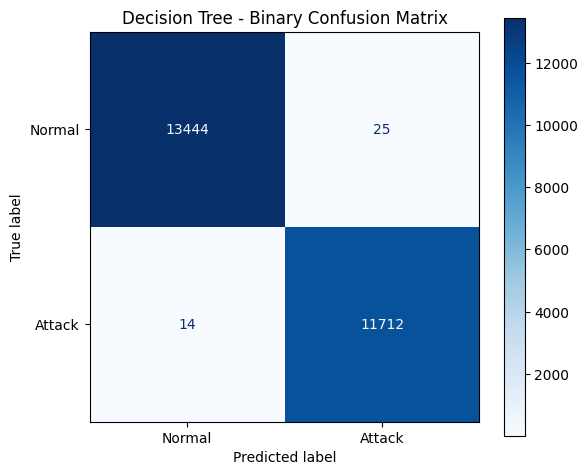

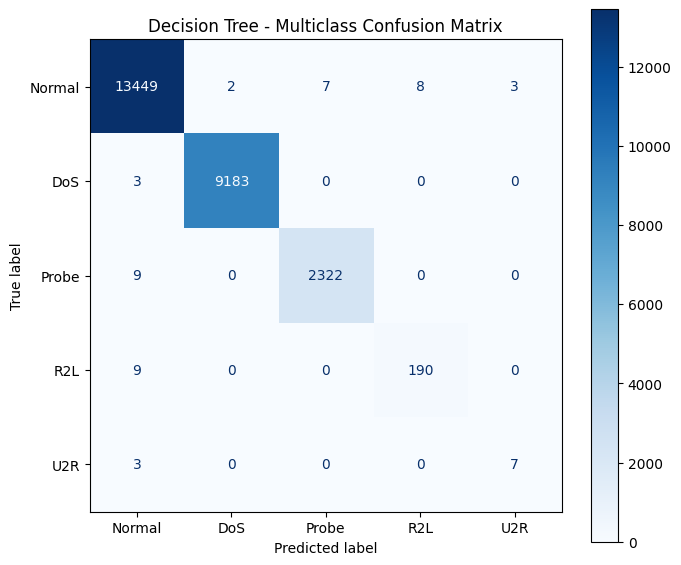

In [13]:
# Decision Tree - Binary Confusion Matrix

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_binary_val,
    y_binary_dt_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Decision Tree - Binary Confusion Matrix")
plt.tight_layout()
plt.show()


# Decision Tree - Multiclass Confusion Matrix

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_multiclass_val,
    y_multiclass_dt_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    display_labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Decision Tree - Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

Task 3 — Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

random_forest_binary = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_binary.fit(
    X_train_processed,
    y_binary_train
)


random_forest_multiclass = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_multiclass.fit(
    X_train_processed,
    y_multiclass_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [15]:
y_binary_rf_pred = random_forest_binary.predict(X_val_processed)
y_multiclass_rf_pred = random_forest_multiclass.predict(X_val_processed)

print("RANDOM FOREST — BINARY")
print("----------------------")

print(classification_report(
    y_binary_val,
    y_binary_rf_pred,
    target_names=["Normal", "Attack"],
    zero_division=0
))

print("\nRANDOM FOREST — MULTICLASS")
print("--------------------------")

print(classification_report(
    y_multiclass_val,
    y_multiclass_rf_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    zero_division=0
))

RANDOM FOREST — BINARY
----------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


RANDOM FOREST — MULTICLASS
--------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      0.99      1.00      2331
         R2L       1.00      0.95      0.98       199
         U2R       0.89      0.80      0.84        10

    accuracy                           1.00     25195
   macro avg       0.98      0.95      0.96     25195
weighted avg       1.00      1.00      1.00     25195



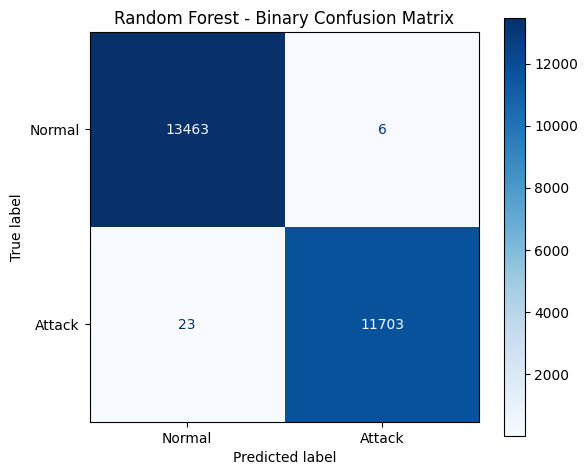

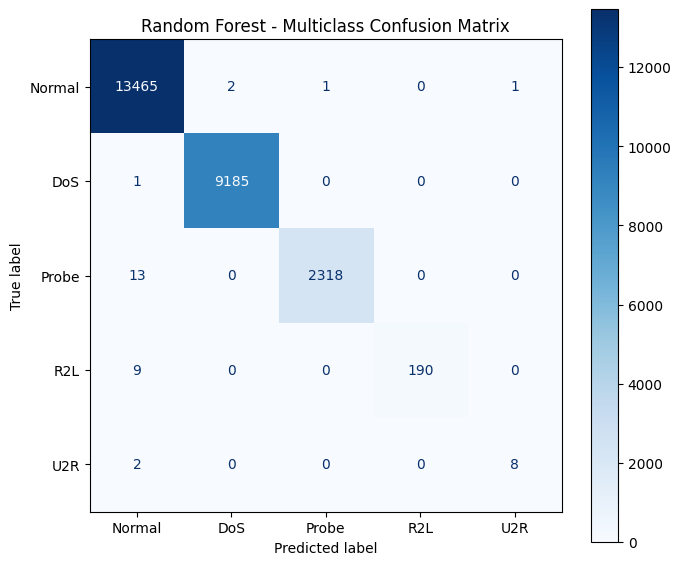

In [16]:
# Binary

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_binary_val,
    y_binary_rf_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Random Forest - Binary Confusion Matrix")
plt.tight_layout()
plt.show()


# Multiclass

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_multiclass_val,
    y_multiclass_rf_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    display_labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("Random Forest - Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
random_forest_results = {
    "Model": "Random Forest",
    "Binary Accuracy": accuracy_score(
        y_binary_val, y_binary_rf_pred
    ),
    "Binary Precision": precision_score(
        y_binary_val, y_binary_rf_pred
    ),
    "Binary Recall": recall_score(
        y_binary_val, y_binary_rf_pred
    ),
    "Binary F1": f1_score(
        y_binary_val, y_binary_rf_pred
    ),
    "Multiclass Accuracy": accuracy_score(
        y_multiclass_val, y_multiclass_rf_pred
    ),
    "Multiclass Macro F1": f1_score(
        y_multiclass_val,
        y_multiclass_rf_pred,
        average="macro"
    ),
    "Multiclass Weighted F1": f1_score(
        y_multiclass_val,
        y_multiclass_rf_pred,
        average="weighted"
    )
}

print(random_forest_results)

{'Model': 'Random Forest', 'Binary Accuracy': 0.9988489779718198, 'Binary Precision': 0.9994875736612862, 'Binary Recall': 0.9980385468190346, 'Binary F1': 0.9987625346703648, 'Multiclass Accuracy': 0.9988489779718198, 'Multiclass Macro F1': 0.9629438546097482, 'Multiclass Weighted F1': 0.9988414467781619}


Task 4 — SVM

In [ ]:
from sklearn.svm import SVC

svm_binary = SVC(
    kernel="linear",
    class_weight="balanced",
    random_state=42
)

svm_binary.fit(
    X_train_processed,
    y_binary_train
)

y_binary_svm_pred = svm_binary.predict(X_val_processed)


svm_multiclass = SVC(
    kernel="linear",
    class_weight="balanced",
    random_state=42
)

svm_multiclass.fit(
    X_train_processed,
    y_multiclass_train
)

y_multiclass_svm_pred = svm_multiclass.predict(X_val_processed)

In [ ]:
print("SVM — BINARY")
print("------------")

print(classification_report(
    y_binary_val,
    y_binary_svm_pred,
    target_names=["Normal", "Attack"],
    zero_division=0
))

print("\nSVM — MULTICLASS")
print("----------------")

print(classification_report(
    y_multiclass_val,
    y_multiclass_svm_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    zero_division=0
))

SVM — BINARY
------------
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98     13469
      Attack       0.98      0.98      0.98     11726

    accuracy                           0.98     25195
   macro avg       0.98      0.98      0.98     25195
weighted avg       0.98      0.98      0.98     25195


SVM — MULTICLASS
----------------
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98     13469
         DoS       1.00      1.00      1.00      9186
       Probe       0.94      0.99      0.97      2331
         R2L       0.36      0.98      0.53       199
         U2R       0.23      0.90      0.36        10

    accuracy                           0.98     25195
   macro avg       0.70      0.97      0.77     25195
weighted avg       0.99      0.98      0.98     25195



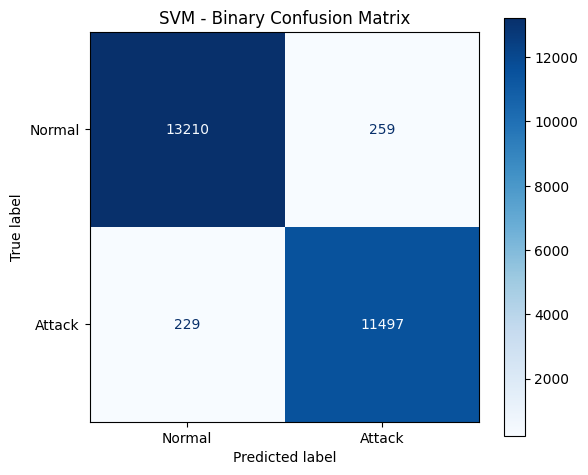

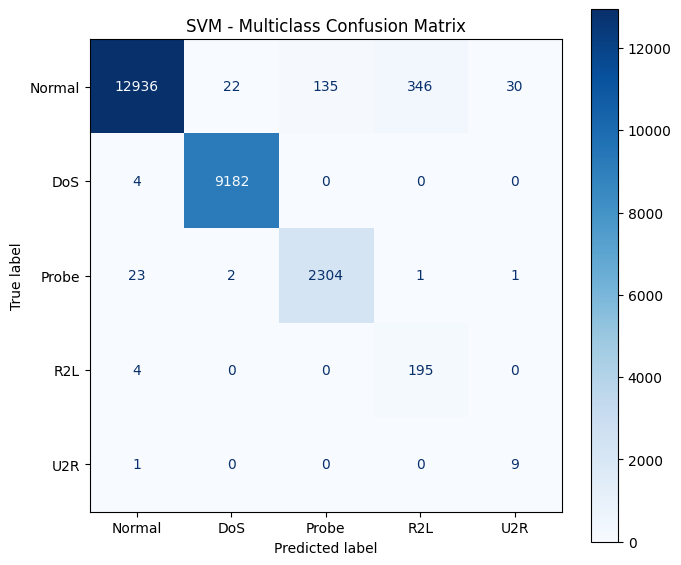

In [ ]:
# Binary

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_binary_val,
    y_binary_svm_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("SVM - Binary Confusion Matrix")
plt.tight_layout()
plt.show()


# Multiclass

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_multiclass_val,
    y_multiclass_svm_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    display_labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("SVM - Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
svm_results = {
    "Model": "SVM",
    "Binary Accuracy": accuracy_score(
        y_binary_val, y_binary_svm_pred
    ),
    "Binary Precision": precision_score(
        y_binary_val, y_binary_svm_pred
    ),
    "Binary Recall": recall_score(
        y_binary_val, y_binary_svm_pred
    ),
    "Binary F1": f1_score(
        y_binary_val, y_binary_svm_pred
    ),
    "Multiclass Accuracy": accuracy_score(
        y_multiclass_val, y_multiclass_svm_pred
    ),
    "Multiclass Macro F1": f1_score(
        y_multiclass_val,
        y_multiclass_svm_pred,
        average="macro"
    ),
    "Multiclass Weighted F1": f1_score(
        y_multiclass_val,
        y_multiclass_svm_pred,
        average="weighted"
    )
}

print(svm_results)

{'Model': 'SVM', 'Binary Accuracy': 0.9806310775947609, 'Binary Precision': 0.9779686968356583, 'Binary Recall': 0.9804707487634317, 'Binary F1': 0.9792181245209096, 'Multiclass Accuracy': 0.9774161539988093, 'Multiclass Macro F1': 0.7658919123392128, 'Multiclass Weighted F1': 0.9808824152392488}


Task 5 — XGBoost

In [ ]:
from xgboost import XGBClassifier

In [44]:
xgb_binary = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_binary.fit(
    X_train_processed,
    y_binary_train
)

y_binary_xgb_pred = xgb_binary.predict(X_val_processed)

In [45]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_multiclass_train_encoded = label_encoder.fit_transform(
    y_multiclass_train
)

y_multiclass_val_encoded = label_encoder.transform(
    y_multiclass_val
)

print(label_encoder.classes_)

['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


In [46]:
xgb_multiclass = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=5,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_multiclass.fit(
    X_train_processed,
    y_multiclass_train_encoded
)

y_multiclass_xgb_pred_encoded = xgb_multiclass.predict(
    X_val_processed
)

y_multiclass_xgb_pred = label_encoder.inverse_transform(
    y_multiclass_xgb_pred_encoded
)

In [47]:
print("XGBOOST — BINARY")
print("----------------")

print(classification_report(
    y_binary_val,
    y_binary_xgb_pred,
    target_names=["Normal", "Attack"],
    zero_division=0
))


print("\nXGBOOST — MULTICLASS")
print("--------------------")

print(classification_report(
    y_multiclass_val,
    y_multiclass_xgb_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    zero_division=0
))

XGBOOST — BINARY
----------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
      Attack       1.00      1.00      1.00     11726

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195


XGBOOST — MULTICLASS
--------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       1.00      0.98      0.99       199
         U2R       0.75      0.90      0.82        10

    accuracy                           1.00     25195
   macro avg       0.95      0.98      0.96     25195
weighted avg       1.00      1.00      1.00     25195



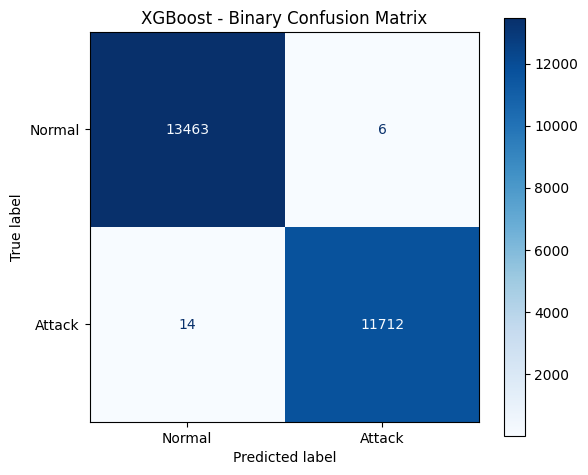

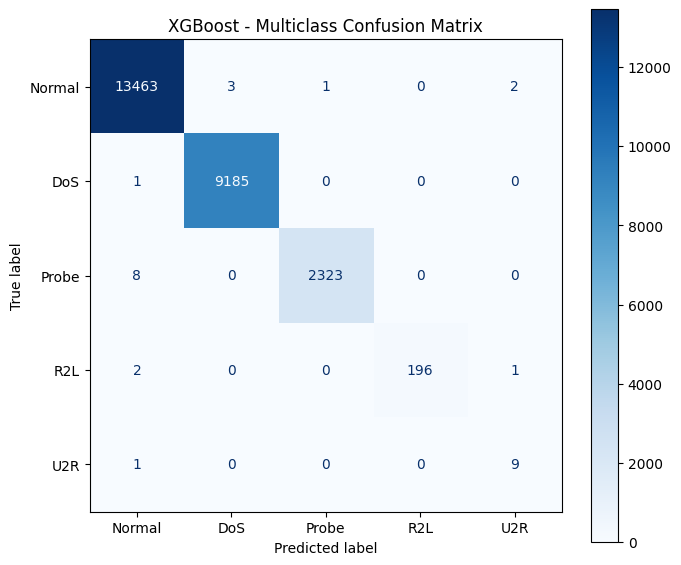

In [48]:
# Binary

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_binary_val,
    y_binary_xgb_pred,
    display_labels=["Normal", "Attack"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("XGBoost - Binary Confusion Matrix")
plt.tight_layout()
plt.show()


# Multiclass

fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_multiclass_val,
    y_multiclass_xgb_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    display_labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("XGBoost - Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

In [49]:
xgboost_results = {
    "Model": "XGBoost",
    "Binary Accuracy": accuracy_score(
        y_binary_val, y_binary_xgb_pred
    ),
    "Binary Precision": precision_score(
        y_binary_val, y_binary_xgb_pred
    ),
    "Binary Recall": recall_score(
        y_binary_val, y_binary_xgb_pred
    ),
    "Binary F1": f1_score(
        y_binary_val, y_binary_xgb_pred
    ),
    "Multiclass Accuracy": accuracy_score(
        y_multiclass_val, y_multiclass_xgb_pred
    ),
    "Multiclass Macro F1": f1_score(
        y_multiclass_val,
        y_multiclass_xgb_pred,
        average="macro"
    ),
    "Multiclass Weighted F1": f1_score(
        y_multiclass_val,
        y_multiclass_xgb_pred,
        average="weighted"
    )
}

print(xgboost_results)

{'Model': 'XGBoost', 'Binary Accuracy': 0.9992061917047033, 'Binary Precision': 0.9994879672299027, 'Binary Recall': 0.9988060719768037, 'Binary F1': 0.9991469032588296, 'Multiclass Accuracy': 0.9992458821194682, 'Multiclass Macro F1': 0.9615535450706222, 'Multiclass Weighted F1': 0.9992524659938541}


Compare all 5 models

In [ ]:
all_results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results,
    svm_results,
    xgboost_results
])

all_results

,Model,Binary Accuracy,Binary Precision,Binary Recall,Binary F1,Multiclass Accuracy,Multiclass Macro F1,Multiclass Weighted F1
0,Logistic Regression,0.976186,0.979817,0.968787,0.974271,0.991665,0.861296,0.991607
1,Decision Tree,0.998452,0.997870,0.998806,0.998338,0.998254,0.930368,0.998253
2,Random Forest,0.998849,0.999488,0.998039,0.998763,0.998849,0.962944,0.998841
3,SVM,0.980631,0.977969,0.980471,0.979218,0.977416,0.765892,0.980882
4,XGBoost,0.999206,0.999488,0.998806,0.999147,0.999246,0.961554,0.999252


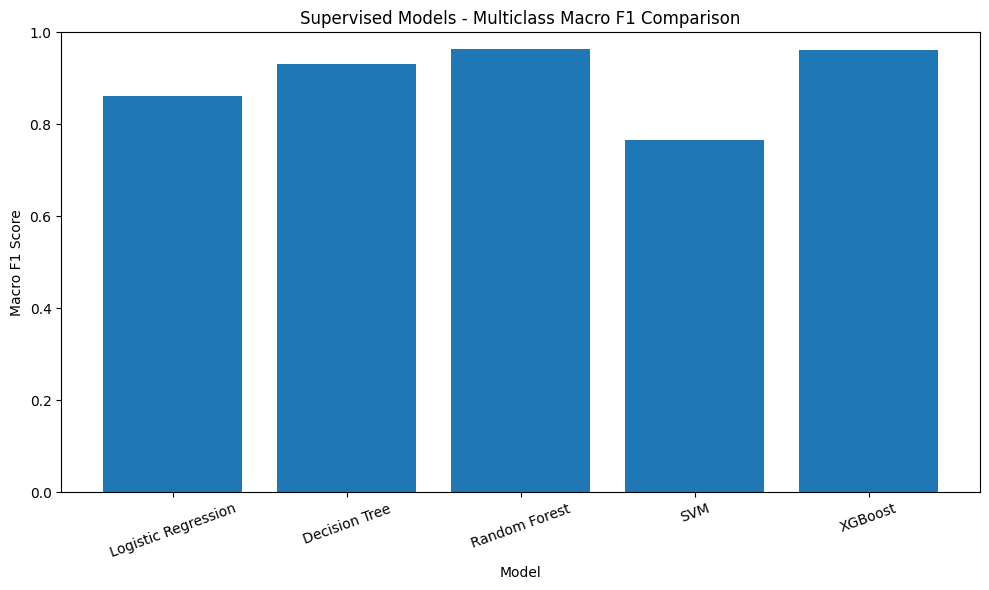

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    all_results["Model"],
    all_results["Multiclass Macro F1"]
)

plt.ylabel("Macro F1 Score")
plt.xlabel("Model")
plt.title("Supervised Models - Multiclass Macro F1 Comparison")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
best_model = all_results.loc[
    all_results["Multiclass Macro F1"].idxmax()
]

print("Best Multiclass Model")
print("---------------------")
print("Model:", best_model["Model"])
print("Macro F1:", round(best_model["Multiclass Macro F1"], 4))
print("Accuracy:", round(best_model["Multiclass Accuracy"], 4))
print("Weighted F1:", round(best_model["Multiclass Weighted F1"], 4))

Best Multiclass Model
---------------------
Model: Random Forest
Macro F1: 0.9629
Accuracy: 0.9988
Weighted F1: 0.9988


Random Forest Feature Importance

In [ ]:
# Load the feature names saved from preprocessing

feature_names = np.load(
    "../data/processed/feature_names.npy",
    allow_pickle=True
)

print("Number of feature names:", len(feature_names))

Number of feature names: 121


In [ ]:
feature_names = np.load(
    "../data/processed/feature_names.npy",
    allow_pickle=True
)

import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": random_forest_multiclass.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
0,log_numeric__src_bytes,0.083208
28,numeric__dst_host_srv_count,0.068674
1,log_numeric__dst_bytes,0.065721
30,numeric__dst_host_diff_srv_rate,0.038396
18,numeric__count,0.036231
33,numeric__dst_host_serror_rate,0.036094
19,numeric__srv_count,0.035134
8,numeric__logged_in,0.035033
27,numeric__dst_host_count,0.031697
31,numeric__dst_host_same_src_port_rate,0.030910


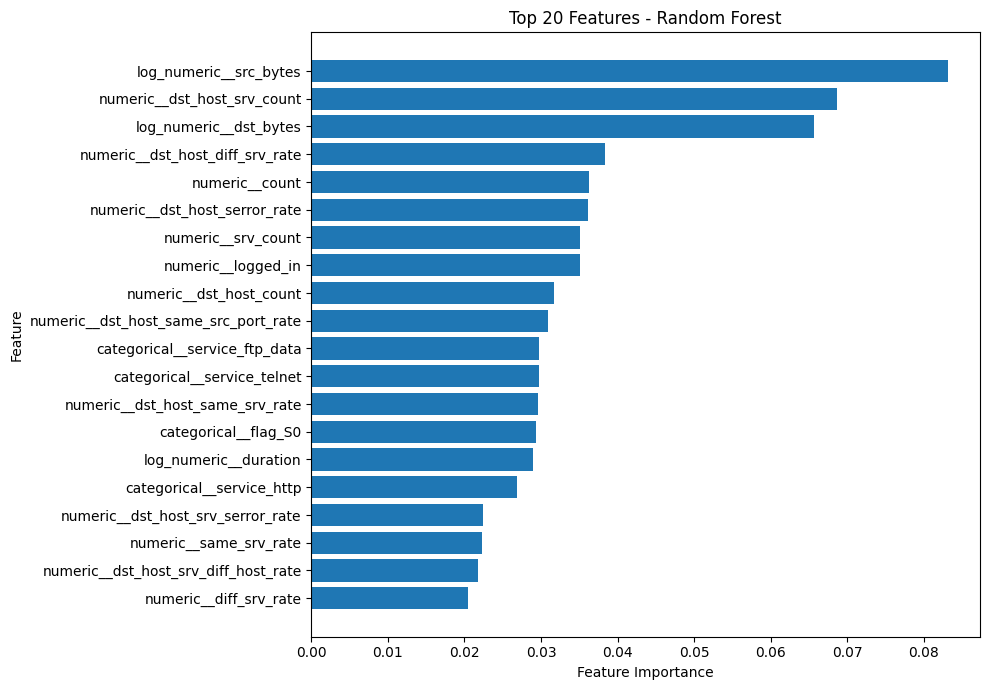

In [ ]:
top_features = feature_importance_df.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features - Random Forest")
plt.tight_layout()
plt.show()

In [22]:
import joblib

joblib.dump(
    random_forest_binary,
    "../models/random_forest_binary.joblib"
)

print("Binary Random Forest saved successfully.")

Binary Random Forest saved successfully.


Improve Random Forest Generalization

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

rf_configs = {
    "RF_200_balanced": {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    "RF_300_balanced": {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 1
    },
    "RF_300_depth20": {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1
    },
    "RF_300_depth30_leaf2": {
        "n_estimators": 300,
        "max_depth": 30,
        "min_samples_leaf": 2
    }
}

rf_tuning_results = []

for name, config in rf_configs.items():

    print(f"\nTraining {name}...")

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_processed, y_binary_train)

    y_pred = model.predict(X_val_processed)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_binary_val, y_pred),
        "Precision": precision_score(y_binary_val, y_pred),
        "Recall": recall_score(y_binary_val, y_pred),
        "F1": f1_score(y_binary_val, y_pred)
    }

    rf_tuning_results.append(result)

rf_tuning_df = pd.DataFrame(rf_tuning_results)
rf_tuning_df


Training RF_200_balanced...

Training RF_300_balanced...

Training RF_300_depth20...

Training RF_300_depth30_leaf2...


,Model,Accuracy,Precision,Recall,F1
0,RF_200_balanced,0.998849,0.999488,0.998039,0.998763
1,RF_300_balanced,0.998928,0.999573,0.998124,0.998848
2,RF_300_depth20,0.998611,0.999658,0.997356,0.998506
3,RF_300_depth30_leaf2,0.998412,0.999487,0.997100,0.998292


In [24]:
rf_multiclass_results = []

for name, config in rf_configs.items():

    print(f"\nTraining {name}...")

    model = RandomForestClassifier(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        min_samples_leaf=config["min_samples_leaf"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_processed, y_multiclass_train)

    y_pred = model.predict(X_val_processed)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_multiclass_val, y_pred),
        "Macro Precision": precision_score(
            y_multiclass_val, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_multiclass_val, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_multiclass_val, y_pred, average="macro", zero_division=0
        ),
        "Weighted F1": f1_score(
            y_multiclass_val, y_pred, average="weighted", zero_division=0
        )
    }

    rf_multiclass_results.append(result)

rf_multiclass_df = pd.DataFrame(rf_multiclass_results)
rf_multiclass_df


Training RF_200_balanced...

Training RF_300_balanced...

Training RF_300_depth20...

Training RF_300_depth30_leaf2...


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,RF_200_balanced,0.998849,0.977277,0.949758,0.962944,0.998841
1,RF_300_balanced,0.998849,0.977277,0.949758,0.962944,0.998841
2,RF_300_depth20,0.998809,0.977452,0.971567,0.974476,0.998806
3,RF_300_depth30_leaf2,0.998611,0.956930,0.973551,0.964848,0.998614


In [25]:
best_rf_config_name = rf_multiclass_df.loc[
    rf_multiclass_df["Macro F1"].idxmax(),
    "Model"
]

print("Best Random Forest configuration:")
print(best_rf_config_name)

print("\nResults:")
display(
    rf_multiclass_df.sort_values(
        by="Macro F1",
        ascending=False
    )
)

Best Random Forest configuration:
RF_300_depth20

Results:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
2,RF_300_depth20,0.998809,0.977452,0.971567,0.974476,0.998806
3,RF_300_depth30_leaf2,0.998611,0.956930,0.973551,0.964848,0.998614
1,RF_300_balanced,0.998849,0.977277,0.949758,0.962944,0.998841
0,RF_200_balanced,0.998849,0.977277,0.949758,0.962944,0.998841


In [26]:
best_config = rf_configs[best_rf_config_name]

final_random_forest = RandomForestClassifier(
    n_estimators=best_config["n_estimators"],
    max_depth=best_config["max_depth"],
    min_samples_leaf=best_config["min_samples_leaf"],
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_random_forest.fit(
    X_train_processed,
    y_multiclass_train
)

joblib.dump(
    final_random_forest,
    "../models/random_forest_multiclass_final.joblib"
)

print("Final Random Forest saved.")

Final Random Forest saved.


In [27]:
# Train and save the best binary Random Forest

final_random_forest_binary = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_random_forest_binary.fit(
    X_train_processed,
    y_binary_train
)

joblib.dump(
    final_random_forest_binary,
    "../models/random_forest_binary_tuned.joblib"
)

print("Best binary Random Forest saved.")

Best binary Random Forest saved.


In [28]:
# Get probability of the "Attack" class

y_val_proba = final_random_forest_binary.predict_proba(
    X_val_processed
)[:, 1]

print("Validation probabilities generated.")
print("Minimum:", y_val_proba.min())
print("Maximum:", y_val_proba.max())

Validation probabilities generated.
Minimum: 0.0
Maximum: 1.0


In [29]:
thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results = []

for threshold in thresholds:

    y_val_threshold_pred = (
        y_val_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_binary_val,
            y_val_threshold_pred
        ),
        "Precision": precision_score(
            y_binary_val,
            y_val_threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_binary_val,
            y_val_threshold_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_binary_val,
            y_val_threshold_pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Accuracy,Precision,Recall,F1
0,0.10,0.995991,0.991626,0.999829,0.995711
1,0.15,0.997222,0.994317,0.999744,0.997023
2,0.20,0.998174,0.996345,0.999744,0.998042
3,0.25,0.998651,0.997617,0.999488,0.998552
4,0.30,0.999047,0.998467,0.999488,0.998977
5,0.35,0.999167,0.998977,0.999232,0.999105
6,0.40,0.999167,0.999232,0.998977,0.999104
7,0.45,0.999008,0.999402,0.998465,0.998933
8,0.50,0.998928,0.999573,0.998124,0.998848


In [30]:
display(
    threshold_df[
        ["Threshold", "Precision", "Recall", "F1"]
    ].sort_values(
        by="F1",
        ascending=False
    )
)

,Threshold,Precision,Recall,F1
5,0.35,0.998977,0.999232,0.999105
6,0.40,0.999232,0.998977,0.999104
4,0.30,0.998467,0.999488,0.998977
7,0.45,0.999402,0.998465,0.998933
8,0.50,0.999573,0.998124,0.998848
3,0.25,0.997617,0.999488,0.998552
2,0.20,0.996345,0.999744,0.998042
1,0.15,0.994317,0.999744,0.997023
0,0.10,0.991626,0.999829,0.995711


In [31]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

best_validation_f1 = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "F1"
]

print("Best threshold:", best_threshold)
print("Validation F1:", best_validation_f1)

Best threshold: 0.35
Validation F1: 0.9991046685141761


In [34]:
# Attack-only data for the second-stage classifier

attack_train_mask = y_multiclass_train != "Normal"
attack_val_mask = y_multiclass_val != "Normal"

X_attack_train = X_train_processed[attack_train_mask]
y_attack_train = y_multiclass_train[attack_train_mask]

X_attack_val = X_val_processed[attack_val_mask]
y_attack_val = y_multiclass_val[attack_val_mask]

print("Attack training shape:", X_attack_train.shape)
print("Attack validation shape:", X_attack_val.shape)

print("\nAttack training distribution:")
print(pd.Series(y_attack_train).value_counts())

print("\nAttack validation distribution:")
print(pd.Series(y_attack_val).value_counts())

Attack training shape: (46904, 121)
Attack validation shape: (11726, 121)

Attack training distribution:
DoS      36741
Probe     9325
R2L        796
U2R         42
Name: count, dtype: int64

Attack validation distribution:
DoS      9186
Probe    2331
R2L       199
U2R        10
Name: count, dtype: int64


In [35]:
# Second-stage Random Forest:
# classify attack traffic into DoS / Probe / R2L / U2R

hierarchical_attack_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

hierarchical_attack_rf.fit(
    X_attack_train,
    y_attack_train
)

print("Hierarchical attack classifier trained.")

Hierarchical attack classifier trained.


In [36]:
y_attack_val_pred = hierarchical_attack_rf.predict(
    X_attack_val
)

print("Attack-only classification results")
print("-----------------------------------")

print(
    classification_report(
        y_attack_val,
        y_attack_val_pred,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

hierarchical_attack_macro_f1 = f1_score(
    y_attack_val,
    y_attack_val_pred,
    average="macro"
)

print("Attack-only Macro F1:", hierarchical_attack_macro_f1)

Attack-only classification results
-----------------------------------
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      1.00      1.00       199
         U2R       1.00      1.00      1.00        10

    accuracy                           1.00     11726
   macro avg       1.00      1.00      1.00     11726
weighted avg       1.00      1.00      1.00     11726

Attack-only Macro F1: 0.9993197970252815


In [37]:
joblib.dump(
    hierarchical_attack_rf,
    "../models/hierarchical_attack_rf.joblib"
)

print("Hierarchical attack classifier saved.")

Hierarchical attack classifier saved.


In [38]:
# Stage 1: Binary detection using the frozen 0.35 threshold

y_val_binary_proba = (
    final_random_forest_binary.predict_proba(
        X_val_processed
    )[:, 1]
)

y_val_binary_pred = (
    y_val_binary_proba >= 0.35
).astype(int)


# Stage 2: Classify only samples predicted as Attack

hierarchical_val_pred = np.empty(
    len(y_multiclass_val),
    dtype=object
)

# Initially assume everything is Normal
hierarchical_val_pred[:] = "Normal"

attack_indices = np.where(
    y_val_binary_pred == 1
)[0]

hierarchical_val_pred[attack_indices] = (
    hierarchical_attack_rf.predict(
        X_val_processed[attack_indices]
    )
)

print("Hierarchical validation predictions generated.")

Hierarchical validation predictions generated.


In [39]:
print("Hierarchical Classification - Validation")
print("----------------------------------------")

print(
    classification_report(
        y_multiclass_val,
        hierarchical_val_pred,
        labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

hierarchical_accuracy = accuracy_score(
    y_multiclass_val,
    hierarchical_val_pred
)

hierarchical_macro_f1 = f1_score(
    y_multiclass_val,
    hierarchical_val_pred,
    average="macro"
)

hierarchical_weighted_f1 = f1_score(
    y_multiclass_val,
    hierarchical_val_pred,
    average="weighted"
)

print("Accuracy :", hierarchical_accuracy)
print("Macro F1 :", hierarchical_macro_f1)
print("Weighted F1:", hierarchical_weighted_f1)

Hierarchical Classification - Validation
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      0.98      0.99       199
         U2R       0.83      1.00      0.91        10

    accuracy                           1.00     25195
   macro avg       0.96      1.00      0.98     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy : 0.9991665012899384
Macro F1 : 0.9786708189721786
Weighted F1: 0.9991698217931544


In [40]:
hierarchical_cm = confusion_matrix(
    y_multiclass_val,
    hierarchical_val_pred,
    labels=["Normal", "DoS", "Probe", "R2L", "U2R"]
)

print("Hierarchical Confusion Matrix:")
print(hierarchical_cm)

Hierarchical Confusion Matrix:
[[13457     3     5     2     2]
 [    1  9185     0     0     0]
 [    5     0  2326     0     0]
 [    3     0     0   196     0]
 [    0     0     0     0    10]]


In [41]:
joblib.dump(
    hierarchical_attack_rf,
    "../models/hierarchical_attack_rf.joblib"
)

print("Hierarchical attack classifier saved.")

Hierarchical attack classifier saved.


In [50]:
joblib.dump(
    xgb_multiclass,
    "../models/xgboost_multiclass.joblib"
)

print("XGBoost multiclass model saved.")

XGBoost multiclass model saved.


In [51]:
joblib.dump(
    label_encoder,
    "../models/xgboost_multiclass_label_encoder.joblib"
)

print("XGBoost label encoder saved.")

XGBoost label encoder saved.


In [52]:
from sklearn.utils import resample

# Separate attack classes
X_dos = X_attack_train[y_attack_train == "DoS"]
X_probe = X_attack_train[y_attack_train == "Probe"]
X_r2l = X_attack_train[y_attack_train == "R2L"]
X_u2r = X_attack_train[y_attack_train == "U2R"]

y_dos = y_attack_train[y_attack_train == "DoS"]
y_probe = y_attack_train[y_attack_train == "Probe"]
y_r2l = y_attack_train[y_attack_train == "R2L"]
y_u2r = y_attack_train[y_attack_train == "U2R"]


# Target sizes
R2L_TARGET = 3000
U2R_TARGET = 1000


# Oversample R2L
X_r2l_over, y_r2l_over = resample(
    X_r2l,
    y_r2l,
    replace=True,
    n_samples=R2L_TARGET,
    random_state=42
)


# Oversample U2R
X_u2r_over, y_u2r_over = resample(
    X_u2r,
    y_u2r,
    replace=True,
    n_samples=U2R_TARGET,
    random_state=42
)


# Combine everything
X_attack_train_over = np.vstack([
    X_dos,
    X_probe,
    X_r2l_over,
    X_u2r_over
])

y_attack_train_over = np.concatenate([
    y_dos,
    y_probe,
    y_r2l_over,
    y_u2r_over
])


print("Oversampled training distribution:")
print(pd.Series(y_attack_train_over).value_counts())

Oversampled training distribution:
DoS      36741
Probe     9325
R2L       3000
U2R       1000
Name: count, dtype: int64


In [53]:
hierarchical_attack_rf_over = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

hierarchical_attack_rf_over.fit(
    X_attack_train_over,
    y_attack_train_over
)

print("Oversampled hierarchical attack classifier trained.")

Oversampled hierarchical attack classifier trained.


In [54]:
y_attack_val_pred_over = (
    hierarchical_attack_rf_over.predict(
        X_attack_val
    )
)

print("Oversampled Attack-only Validation")
print("-----------------------------------")

print(
    classification_report(
        y_attack_val,
        y_attack_val_pred_over,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print(
    "Macro F1:",
    f1_score(
        y_attack_val,
        y_attack_val_pred_over,
        average="macro"
    )
)

Oversampled Attack-only Validation
-----------------------------------
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      1.00      1.00       199
         U2R       1.00      1.00      1.00        10

    accuracy                           1.00     11726
   macro avg       1.00      1.00      1.00     11726
weighted avg       1.00      1.00      1.00     11726

Macro F1: 0.9993197970252815


In [55]:
# Stage 1: existing binary detector
y_val_binary_proba = (
    final_random_forest_binary.predict_proba(
        X_val_processed
    )[:, 1]
)

y_val_binary_pred = (
    y_val_binary_proba >= 0.35
).astype(int)


# Stage 2: oversampled attack classifier
hierarchical_over_val_pred = np.empty(
    len(y_multiclass_val),
    dtype=object
)

hierarchical_over_val_pred[:] = "Normal"

attack_indices = np.where(
    y_val_binary_pred == 1
)[0]

hierarchical_over_val_pred[attack_indices] = (
    hierarchical_attack_rf_over.predict(
        X_val_processed[attack_indices]
    )
)


print("Oversampled Hierarchical Validation")
print("------------------------------------")

print(
    classification_report(
        y_multiclass_val,
        hierarchical_over_val_pred,
        labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_multiclass_val,
        hierarchical_over_val_pred
    )
)

print(
    "Macro F1:",
    f1_score(
        y_multiclass_val,
        hierarchical_over_val_pred,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_multiclass_val,
        hierarchical_over_val_pred,
        average="weighted"
    )
)

Oversampled Hierarchical Validation
------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      0.98      0.99       199
         U2R       0.83      1.00      0.91        10

    accuracy                           1.00     25195
   macro avg       0.96      1.00      0.98     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy: 0.9991665012899384
Macro F1: 0.9786708189721786
Weighted F1: 0.9991698217931544


In [56]:
from sklearn.base import clone

attack_classes = ["DoS", "Probe", "R2L", "U2R"]

ovr_attack_models = {}
ovr_validation_probabilities = {}

for attack_class in attack_classes:

    print(f"Training One-vs-Rest classifier: {attack_class}")

    # 1 = current attack category
    # 0 = all other attack categories
    y_binary_attack = (
        y_attack_train == attack_class
    ).astype(int)

    model = RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_attack_train,
        y_binary_attack
    )

    # Probability that each validation attack belongs
    # to this particular category
    y_val_probability = model.predict_proba(
        X_attack_val
    )[:, 1]

    ovr_attack_models[attack_class] = model
    ovr_validation_probabilities[attack_class] = y_val_probability

print("\nAll One-vs-Rest classifiers trained.")

Training One-vs-Rest classifier: DoS
Training One-vs-Rest classifier: Probe
Training One-vs-Rest classifier: R2L
Training One-vs-Rest classifier: U2R

All One-vs-Rest classifiers trained.


In [57]:
# Build probability matrix
# Columns: DoS, Probe, R2L, U2R

ovr_probability_matrix = np.column_stack([
    ovr_validation_probabilities["DoS"],
    ovr_validation_probabilities["Probe"],
    ovr_validation_probabilities["R2L"],
    ovr_validation_probabilities["U2R"]
])

# Select the category with the highest probability
ovr_prediction_indices = np.argmax(
    ovr_probability_matrix,
    axis=1
)

ovr_attack_predictions = np.array(
    attack_classes
)[ovr_prediction_indices]

print("One-vs-Rest attack predictions generated.")

One-vs-Rest attack predictions generated.


In [58]:
print("One-vs-Rest Attack-only Validation")
print("-----------------------------------")

print(
    classification_report(
        y_attack_val,
        ovr_attack_predictions,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

ovr_attack_macro_f1 = f1_score(
    y_attack_val,
    ovr_attack_predictions,
    average="macro"
)

print("Attack-only Macro F1:", ovr_attack_macro_f1)

One-vs-Rest Attack-only Validation
-----------------------------------
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      1.00      1.00       199
         U2R       1.00      0.90      0.95        10

    accuracy                           1.00     11726
   macro avg       1.00      0.97      0.99     11726
weighted avg       1.00      1.00      1.00     11726

Attack-only Macro F1: 0.9861482953652368


In [59]:
# Complete hierarchical One-vs-Rest system

y_val_binary_proba = (
    final_random_forest_binary.predict_proba(
        X_val_processed
    )[:, 1]
)

y_val_binary_pred = (
    y_val_binary_proba >= 0.35
).astype(int)


ovr_hierarchical_val_pred = np.empty(
    len(y_multiclass_val),
    dtype=object
)

ovr_hierarchical_val_pred[:] = "Normal"


attack_indices = np.where(
    y_val_binary_pred == 1
)[0]


# Get probabilities from all four OVR models
ovr_full_probability_matrix = np.column_stack([
    ovr_attack_models["DoS"].predict_proba(
        X_val_processed[attack_indices]
    )[:, 1],

    ovr_attack_models["Probe"].predict_proba(
        X_val_processed[attack_indices]
    )[:, 1],

    ovr_attack_models["R2L"].predict_proba(
        X_val_processed[attack_indices]
    )[:, 1],

    ovr_attack_models["U2R"].predict_proba(
        X_val_processed[attack_indices]
    )[:, 1]
])


ovr_full_indices = np.argmax(
    ovr_full_probability_matrix,
    axis=1
)


ovr_hierarchical_val_pred[attack_indices] = (
    np.array(attack_classes)[ovr_full_indices]
)


print("One-vs-Rest Hierarchical Validation")
print("------------------------------------")

print(
    classification_report(
        y_multiclass_val,
        ovr_hierarchical_val_pred,
        labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_multiclass_val,
        ovr_hierarchical_val_pred
    )
)

print(
    "Macro F1:",
    f1_score(
        y_multiclass_val,
        ovr_hierarchical_val_pred,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_multiclass_val,
        ovr_hierarchical_val_pred,
        average="weighted"
    )
)

One-vs-Rest Hierarchical Validation
------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      0.98      0.99       199
         U2R       0.82      0.90      0.86        10

    accuracy                           1.00     25195
   macro avg       0.96      0.98      0.97     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy: 0.9991268108751736
Macro F1: 0.9682703265983388
Weighted F1: 0.9991293657481004


In [60]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Encode the four attack categories
hier_xgb_encoder = LabelEncoder()

y_attack_train_encoded = hier_xgb_encoder.fit_transform(
    y_attack_train
)

y_attack_val_encoded = hier_xgb_encoder.transform(
    y_attack_val
)

print("Attack classes:")
print(hier_xgb_encoder.classes_)

Attack classes:
['DoS' 'Probe' 'R2L' 'U2R']


In [61]:
hierarchical_attack_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=4,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

hierarchical_attack_xgb.fit(
    X_attack_train,
    y_attack_train_encoded
)

print("Hierarchical XGBoost trained.")

Hierarchical XGBoost trained.


In [62]:
y_attack_xgb_val_encoded = (
    hierarchical_attack_xgb.predict(
        X_attack_val
    )
)

y_attack_xgb_val_pred = (
    hier_xgb_encoder.inverse_transform(
        y_attack_xgb_val_encoded.astype(int)
    )
)

print("Hierarchical XGBoost Attack-only Validation")
print("---------------------------------------------")

print(
    classification_report(
        y_attack_val,
        y_attack_xgb_val_pred,
        labels=["DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print(
    "Attack-only Macro F1:",
    f1_score(
        y_attack_val,
        y_attack_xgb_val_pred,
        average="macro"
    )
)

Hierarchical XGBoost Attack-only Validation
---------------------------------------------
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      1.00      1.00       199
         U2R       1.00      0.90      0.95        10

    accuracy                           1.00     11726
   macro avg       1.00      0.97      0.99     11726
weighted avg       1.00      1.00      1.00     11726

Attack-only Macro F1: 0.9861482953652368


In [63]:
# Stage 1: existing binary RF with frozen threshold
y_val_binary_proba = (
    final_random_forest_binary.predict_proba(
        X_val_processed
    )[:, 1]
)

y_val_binary_pred = (
    y_val_binary_proba >= 0.35
).astype(int)


# Stage 2: hierarchical XGBoost
hierarchical_xgb_val_pred = np.empty(
    len(y_multiclass_val),
    dtype=object
)

hierarchical_xgb_val_pred[:] = "Normal"

attack_indices = np.where(
    y_val_binary_pred == 1
)[0]

attack_predictions_encoded = (
    hierarchical_attack_xgb.predict(
        X_val_processed[attack_indices]
    )
)

attack_predictions = (
    hier_xgb_encoder.inverse_transform(
        attack_predictions_encoded.astype(int)
    )
)

hierarchical_xgb_val_pred[attack_indices] = (
    attack_predictions
)


print("Hierarchical XGBoost Validation")
print("--------------------------------")

print(
    classification_report(
        y_multiclass_val,
        hierarchical_xgb_val_pred,
        labels=["Normal", "DoS", "Probe", "R2L", "U2R"],
        zero_division=0
    )
)

print(
    "Accuracy:",
    accuracy_score(
        y_multiclass_val,
        hierarchical_xgb_val_pred
    )
)

print(
    "Macro F1:",
    f1_score(
        y_multiclass_val,
        hierarchical_xgb_val_pred,
        average="macro"
    )
)

print(
    "Weighted F1:",
    f1_score(
        y_multiclass_val,
        hierarchical_xgb_val_pred,
        average="weighted"
    )
)

Hierarchical XGBoost Validation
--------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     13469
         DoS       1.00      1.00      1.00      9186
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      0.98      0.99       199
         U2R       0.82      0.90      0.86        10

    accuracy                           1.00     25195
   macro avg       0.96      0.98      0.97     25195
weighted avg       1.00      1.00      1.00     25195

Accuracy: 0.9991268108751736
Macro F1: 0.9682703265983388
Weighted F1: 0.9991293657481004


## Random Forest on PCA components

In [8]:
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# PCA training representation
X_pca = np.load("../data/processed/X_pca.npy")

# Labels
y_multiclass_train = np.load(
    "../data/processed/y_multiclass_train.npy",
    allow_pickle=True
)

y_multiclass_val = np.load(
    "../data/processed/y_multiclass_val.npy",
    allow_pickle=True
)

print("X_pca:", X_pca.shape)
print("Training labels:", y_multiclass_train.shape)
print("Validation labels:", y_multiclass_val.shape)

X_pca: (100778, 23)
Training labels: (100778,)
Validation labels: (25195,)


In [9]:
X_train_processed = np.load(
    "../data/processed/X_train_processed.npy"
)

X_val_processed = np.load(
    "../data/processed/X_val_processed.npy"
)

print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)

X_train_processed: (100778, 121)
X_val_processed: (25195, 121)


In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=23)

# Fit PCA ONLY on training data
X_train_pca = pca.fit_transform(X_train_processed)

# Transform validation data using the same fitted PCA
X_val_pca = pca.transform(X_val_processed)

print("X_train_pca:", X_train_pca.shape)
print("X_val_pca:", X_val_pca.shape)

X_train_pca: (100778, 23)
X_val_pca: (25195, 23)


In [11]:
rf_pca = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pca.fit(X_train_pca, y_multiclass_train)

print("Random Forest with 23 PCA components trained.")

Random Forest with 23 PCA components trained.


In [12]:
y_pred_pca = rf_pca.predict(X_val_pca)

print("Accuracy:",
      accuracy_score(y_multiclass_val, y_pred_pca))

print("Weighted Precision:",
      precision_score(
          y_multiclass_val,
          y_pred_pca,
          average="weighted",
          zero_division=0
      ))

print("Weighted Recall:",
      recall_score(
          y_multiclass_val,
          y_pred_pca,
          average="weighted",
          zero_division=0
      ))

print("Weighted F1:",
      f1_score(
          y_multiclass_val,
          y_pred_pca,
          average="weighted",
          zero_division=0
      ))

print("Macro F1:",
      f1_score(
          y_multiclass_val,
          y_pred_pca,
          average="macro",
          zero_division=0
      ))

print("\nClassification Report:")
print(classification_report(
    y_multiclass_val,
    y_pred_pca,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_multiclass_val,
    y_pred_pca
))

Accuracy: 0.9964675530859297
Weighted Precision: 0.9964387623031475
Weighted Recall: 0.9964675530859297
Weighted F1: 0.9964294278991901
Macro F1: 0.8976672254007326

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       0.99      1.00      1.00     13469
       Probe       1.00      0.98      0.99      2331
         R2L       0.99      0.91      0.95       199
         U2R       0.62      0.50      0.56        10

    accuracy                           1.00     25195
   macro avg       0.92      0.88      0.90     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:
[[ 9178     8     0     0     0]
 [    2 13454     8     2     3]
 [    0    43  2288     0     0]
 [    0    18     0   181     0]
 [    0     5     0     0     5]]


## Random Forest with RobustScaler

In [15]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    RobustScaler,
    OneHotEncoder
)

# All 40 usable model-input features
feature_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

# Feature groups
log_features = [
    "src_bytes",
    "dst_bytes",
    "duration"
]

categorical_features = [
    "protocol_type",
    "service",
    "flag"
]

numerical_features = [
    f for f in feature_names
    if f not in categorical_features
]

scaled_numerical_features = [
    f for f in numerical_features
    if f not in log_features
]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Log features:", len(log_features))
print("Remaining numerical:", len(scaled_numerical_features))

Numerical features: 37
Categorical features: 3
Log features: 3
Remaining numerical: 34


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load original training data
train_path = "../data/raw/KDDTrain+.txt"

train_df = pd.read_csv(
    train_path,
    sep="\t",
    header=None
)

# ALL 41 original network features
original_feature_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate"
]

# Add label and difficulty
train_df.columns = original_feature_names + ["label", "difficulty"]

# Remove the constant feature
feature_names = [
    f for f in original_feature_names
    if f != "num_outbound_cmds"
]

# Features
X = train_df[feature_names].copy()

# Binary target
y_binary = (
    train_df["label"] != "normal"
).astype(int)

# Multiclass mapping
attack_category_map = {
    "back": "DoS",
    "land": "DoS",
    "neptune": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",

    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "satan": "Probe",

    "ftp_write": "R2L",
    "guess_passwd": "R2L",
    "imap": "R2L",
    "multihop": "R2L",
    "phf": "R2L",
    "spy": "R2L",
    "warezclient": "R2L",
    "warezmaster": "R2L",

    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "perl": "U2R",
    "rootkit": "U2R",

    "normal": "Normal"
}

y_multiclass = train_df["label"].map(attack_category_map)

# EXACT same split as before
X_train, X_val, y_binary_train_check, y_binary_val_check, \
y_multiclass_train_check, y_multiclass_val_check = train_test_split(
    X,
    y_binary,
    y_multiclass,
    test_size=0.20,
    random_state=42,
    stratify=y_multiclass
)

print("Raw data:", train_df.shape)
print("X:", X.shape)
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("Multiclass train:", y_multiclass_train_check.shape)
print("Multiclass val:", y_multiclass_val_check.shape)

Raw data: (125973, 43)
X: (125973, 40)
X_train: (100778, 40)
X_val: (25195, 40)
Multiclass train: (100778,)
Multiclass val: (25195,)


In [18]:
# RobustScaler preprocessing

log_pipeline_robust = Pipeline([
    ("log", FunctionTransformer(
        np.log1p,
        feature_names_out="one-to-one"
    )),
    ("scaler", RobustScaler())
])

numerical_pipeline_robust = Pipeline([
    ("scaler", RobustScaler())
])

categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor_robust = ColumnTransformer([
    ("log_numeric", log_pipeline_robust, log_features),
    ("numeric", numerical_pipeline_robust, scaled_numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit ONLY on training data
X_train_robust = preprocessor_robust.fit_transform(X_train)

# Transform validation data
X_val_robust = preprocessor_robust.transform(X_val)

print("Robust train:", X_train_robust.shape)
print("Robust validation:", X_val_robust.shape)

Robust train: (100778, 121)
Robust validation: (25195, 121)


In [19]:
rf_robust = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_robust.fit(
    X_train_robust,
    y_multiclass_train_check
)

print("Random Forest with RobustScaler preprocessing trained.")

Random Forest with RobustScaler preprocessing trained.


In [20]:
y_pred_robust = rf_robust.predict(X_val_robust)

print("Accuracy:",
      accuracy_score(y_multiclass_val_check, y_pred_robust))

print("Weighted Precision:",
      precision_score(
          y_multiclass_val_check,
          y_pred_robust,
          average="weighted",
          zero_division=0
      ))

print("Weighted Recall:",
      recall_score(
          y_multiclass_val_check,
          y_pred_robust,
          average="weighted",
          zero_division=0
      ))

print("Weighted F1:",
      f1_score(
          y_multiclass_val_check,
          y_pred_robust,
          average="weighted",
          zero_division=0
      ))

print("Macro F1:",
      f1_score(
          y_multiclass_val_check,
          y_pred_robust,
          average="macro",
          zero_division=0
      ))

print("\nClassification Report:")
print(classification_report(
    y_multiclass_val_check,
    y_pred_robust,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_multiclass_val_check,
    y_pred_robust
))

Accuracy: 0.9987299067275253
Weighted Precision: 0.9987247324247548
Weighted Recall: 0.9987299067275253
Weighted F1: 0.9987238863117821
Macro F1: 0.9628391821772817

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       1.00      0.99      1.00      2331
         R2L       0.99      0.96      0.98       199
         U2R       0.89      0.80      0.84        10

    accuracy                           1.00     25195
   macro avg       0.98      0.95      0.96     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:
[[ 9185     1     0     0     0]
 [    2 13463     1     2     1]
 [    0    16  2315     0     0]
 [    0     7     0   192     0]
 [    0     2     0     0     8]]


## Frequency encoding instead of One Hot

In [21]:
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.frequency_maps_ = {}

    def fit(self, X, y=None):
        X = X.copy()

        for col in X.columns:
            frequencies = X[col].value_counts(normalize=True)
            self.frequency_maps_[col] = frequencies.to_dict()

        return self

    def transform(self, X):
        X = X.copy()

        for col in X.columns:
            X[col] = (
                X[col]
                .map(self.frequency_maps_[col])
                .fillna(0)
            )

        return X

In [22]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import numpy as np

# Feature groups
log_features = [
    "src_bytes",
    "dst_bytes",
    "duration"
]

remaining_numerical = [
    f for f in feature_names
    if f not in ["protocol_type", "service", "flag"]
    and f not in log_features
]

# Numerical: log1p + StandardScaler
log_pipeline = Pipeline([
    ("log", FunctionTransformer(
        np.log1p,
        feature_names_out="one-to-one"
    )),
    ("scaler", StandardScaler())
])

numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# One-hot for protocol_type and flag
onehot_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# Frequency encoding for service
service_pipeline = Pipeline([
    ("frequency", FrequencyEncoder())
])

preprocessor_frequency = ColumnTransformer([
    ("log_numeric", log_pipeline, log_features),
    ("numeric", numerical_pipeline, remaining_numerical),
    ("protocol_flag", onehot_pipeline, ["protocol_type", "flag"]),
    ("service_frequency", service_pipeline, ["service"])
])

In [23]:
X_train_frequency = preprocessor_frequency.fit_transform(X_train)

X_val_frequency = preprocessor_frequency.transform(X_val)

print("Frequency-encoded train:", X_train_frequency.shape)
print("Frequency-encoded validation:", X_val_frequency.shape)

Frequency-encoded train: (100778, 52)
Frequency-encoded validation: (25195, 52)


In [24]:
rf_frequency = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_frequency.fit(
    X_train_frequency,
    y_multiclass_train_check
)

print("Random Forest with Frequency Encoding trained.")

Random Forest with Frequency Encoding trained.


In [25]:
y_pred_frequency = rf_frequency.predict(X_val_frequency)

print("Accuracy:",
      accuracy_score(y_multiclass_val_check, y_pred_frequency))

print("Weighted Precision:",
      precision_score(
          y_multiclass_val_check,
          y_pred_frequency,
          average="weighted",
          zero_division=0
      ))

print("Weighted Recall:",
      recall_score(
          y_multiclass_val_check,
          y_pred_frequency,
          average="weighted",
          zero_division=0
      ))

print("Weighted F1:",
      f1_score(
          y_multiclass_val_check,
          y_pred_frequency,
          average="weighted",
          zero_division=0
      ))

print("Macro F1:",
      f1_score(
          y_multiclass_val_check,
          y_pred_frequency,
          average="macro",
          zero_division=0
      ))

print("\nClassification Report:")
print(classification_report(
    y_multiclass_val_check,
    y_pred_frequency,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_multiclass_val_check,
    y_pred_frequency
))

Accuracy: 0.998809287557055
Weighted Precision: 0.9988045128025774
Weighted Recall: 0.998809287557055
Weighted F1: 0.9988033054552462
Macro F1: 0.9633960063665639

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       1.00      0.99      1.00      2331
         R2L       0.99      0.96      0.98       199
         U2R       0.89      0.80      0.84        10

    accuracy                           1.00     25195
   macro avg       0.98      0.95      0.96     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:
[[ 9185     1     0     0     0]
 [    2 13463     2     1     1]
 [    0    14  2317     0     0]
 [    0     7     0   192     0]
 [    0     2     0     0     8]]


## Trying Target Encoding 

In [26]:
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd
import numpy as np

class MulticlassTargetEncoder(BaseEstimator, TransformerMixin):

    def __init__(self, smoothing=10):
        self.smoothing = smoothing
        self.global_mean_ = None
        self.mapping_ = None

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(y).reset_index(drop=True)
        X = X.reset_index(drop=True)

        data = pd.DataFrame({
            "service": X["service"],
            "target": y
        })

        self.classes_ = sorted(y.unique())

        # Global class probabilities
        self.global_mean_ = {
            cls: (y == cls).mean()
            for cls in self.classes_
        }

        self.mapping_ = {}

        for cls in self.classes_:

            # Count samples of each class per service
            stats = data.groupby("service")["target"].agg(
                count="count",
                mean=lambda x, c=cls: (x == c).mean()
            )

            # Smoothing prevents rare services from getting extreme values
            smoothing_weight = (
                stats["count"] /
                (stats["count"] + self.smoothing)
            )

            encoded = (
                smoothing_weight * stats["mean"]
                + (1 - smoothing_weight) * self.global_mean_[cls]
            )

            self.mapping_[cls] = encoded.to_dict()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        result = pd.DataFrame(index=X.index)

        for cls in self.classes_:
            result[f"service_te_{cls}"] = (
                X["service"]
                .map(self.mapping_[cls])
                .fillna(self.global_mean_[cls])
                .values
            )

        return result

In [27]:
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Numerical feature groups
log_features = [
    "src_bytes",
    "dst_bytes",
    "duration"
]

remaining_numerical = [
    f for f in feature_names
    if f not in ["protocol_type", "service", "flag"]
    and f not in log_features
]

# Log numerical features
log_pipeline = Pipeline([
    ("log", FunctionTransformer(
        np.log1p,
        feature_names_out="one-to-one"
    )),
    ("scaler", StandardScaler())
])

# Remaining numerical features
numerical_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

# protocol_type + flag → One-Hot
onehot_pipeline = Pipeline([
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

# service → Target Encoding
target_pipeline = Pipeline([
    ("target_encode", MulticlassTargetEncoder(smoothing=10))
])

preprocessor_target = ColumnTransformer([
    ("log_numeric", log_pipeline, log_features),
    ("numeric", numerical_pipeline, remaining_numerical),
    ("protocol_flag", onehot_pipeline, ["protocol_type", "flag"]),
    ("service_target", target_pipeline, ["service"])
])

In [28]:
X_train_target = preprocessor_target.fit_transform(
    X_train,
    y_multiclass_train_check
)

X_val_target = preprocessor_target.transform(
    X_val
)

print("Target-encoded train:", X_train_target.shape)
print("Target-encoded validation:", X_val_target.shape)

Target-encoded train: (100778, 56)
Target-encoded validation: (25195, 56)


In [29]:
rf_target = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_target.fit(
    X_train_target,
    y_multiclass_train_check
)

print("Random Forest with Target Encoding trained.")

Random Forest with Target Encoding trained.


In [30]:
y_pred_target = rf_target.predict(X_val_target)

print("Accuracy:",
      accuracy_score(y_multiclass_val_check, y_pred_target))

print("Weighted Precision:",
      precision_score(
          y_multiclass_val_check,
          y_pred_target,
          average="weighted",
          zero_division=0
      ))

print("Weighted Recall:",
      recall_score(
          y_multiclass_val_check,
          y_pred_target,
          average="weighted",
          zero_division=0
      ))

print("Weighted F1:",
      f1_score(
          y_multiclass_val_check,
          y_pred_target,
          average="weighted",
          zero_division=0
      ))

print("Macro F1:",
      f1_score(
          y_multiclass_val_check,
          y_pred_target,
          average="macro",
          zero_division=0
      ))

print("\nClassification Report:")
print(classification_report(
    y_multiclass_val_check,
    y_pred_target,
    zero_division=0
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_multiclass_val_check,
    y_pred_target
))

Accuracy: 0.9991268108751736
Weighted Precision: 0.9991262604917236
Weighted Recall: 0.9991268108751736
Weighted F1: 0.9991249000032324
Macro F1: 0.9758119992513651

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       1.00      1.00      1.00      2331
         R2L       0.99      0.97      0.98       199
         U2R       0.90      0.90      0.90        10

    accuracy                           1.00     25195
   macro avg       0.98      0.97      0.98     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:
[[ 9185     1     0     0     0]
 [    2 13464     1     1     1]
 [    0     9  2322     0     0]
 [    0     6     0   193     0]
 [    0     1     0     0     9]]


## OOF target-encoding

In [32]:
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

# Number of folds
n_splits = 5

skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

classes = sorted(y_multiclass_train_check.unique())

# Store OOF encoded training features
X_train_service_te = np.zeros(
    (len(X_train), len(classes)),
    dtype=float
)

# OOF encoding
for train_idx, holdout_idx in skf.split(X_train, y_multiclass_train_check):

    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_multiclass_train_check.iloc[train_idx]

    X_fold_holdout = X_train.iloc[holdout_idx]

    fold_encoder = MulticlassTargetEncoder(smoothing=10)

    fold_encoder.fit(
        X_fold_train[["service"]],
        y_fold_train
    )

    X_train_service_te[holdout_idx] = fold_encoder.transform(
        X_fold_holdout[["service"]]
    ).values

print("OOF target encoding shape:", X_train_service_te.shape)

OOF target encoding shape: (100778, 5)


In [33]:
final_service_encoder = MulticlassTargetEncoder(smoothing=10)

final_service_encoder.fit(
    X_train[["service"]],
    y_multiclass_train_check
)

X_val_service_te = final_service_encoder.transform(
    X_val[["service"]]
).values

print("Validation target encoding shape:", X_val_service_te.shape)

Validation target encoding shape: (25195, 5)


In [34]:
# Numerical preprocessing
log_features = ["duration", "src_bytes", "dst_bytes"]

remaining_numeric = [
    col for col in numerical_features
    if col not in log_features
]

log_pipeline = Pipeline([
    ("log", FunctionTransformer(
        np.log1p,
        feature_names_out="one-to-one"
    )),
    ("scaler", StandardScaler())
])

numeric_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

protocol_flag_pipeline = ColumnTransformer([
    (
        "protocol",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        ["protocol_type"]
    ),
    (
        "flag",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        ["flag"]
    )
])

# Fit numerical + protocol + flag preprocessing
base_preprocessor = ColumnTransformer([
    ("log_numeric", log_pipeline, log_features),
    ("numeric", numeric_pipeline, remaining_numeric),
    (
        "categorical",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ),
        ["protocol_type", "flag"]
    )
])

X_train_base = base_preprocessor.fit_transform(X_train)
X_val_base = base_preprocessor.transform(X_val)

# Combine with leakage-safe service encoding
X_train_oof_target = np.hstack([
    X_train_base,
    X_train_service_te
])

X_val_oof_target = np.hstack([
    X_val_base,
    X_val_service_te
])

print("OOF Target-encoded train:", X_train_oof_target.shape)
print("OOF Target-encoded validation:", X_val_oof_target.shape)

OOF Target-encoded train: (100778, 56)
OOF Target-encoded validation: (25195, 56)


In [35]:
rf_oof_target = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_oof_target.fit(X_train_oof_target, y_multiclass_train_check)

print("OOF Target Encoding RF trained.")

OOF Target Encoding RF trained.


In [36]:
y_pred_oof_target = rf_oof_target.predict(X_val_oof_target)

print("Accuracy:", accuracy_score(y_multiclass_val_check, y_pred_oof_target))
print("Weighted Precision:", precision_score(
    y_multiclass_val_check, y_pred_oof_target,
    average="weighted", zero_division=0
))
print("Weighted Recall:", recall_score(
    y_multiclass_val_check, y_pred_oof_target,
    average="weighted", zero_division=0
))
print("Weighted F1:", f1_score(
    y_multiclass_val_check, y_pred_oof_target,
    average="weighted", zero_division=0
))
print("Macro F1:", f1_score(
    y_multiclass_val_check, y_pred_oof_target,
    average="macro", zero_division=0
))

print("\nClassification Report:")
print(classification_report(
    y_multiclass_val_check,
    y_pred_oof_target
))

print("\nConfusion Matrix:")
print(confusion_matrix(
    y_multiclass_val_check,
    y_pred_oof_target
))

Accuracy: 0.9989283588013494
Weighted Precision: 0.998927647775319
Weighted Recall: 0.9989283588013494
Weighted F1: 0.9989229809945698
Macro F1: 0.9835534725655956

Classification Report:
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00      9186
      Normal       1.00      1.00      1.00     13469
       Probe       1.00      0.99      1.00      2331
         R2L       0.99      0.95      0.97       199
         U2R       1.00      0.90      0.95        10

    accuracy                           1.00     25195
   macro avg       1.00      0.97      0.98     25195
weighted avg       1.00      1.00      1.00     25195


Confusion Matrix:
[[ 9186     0     0     0     0]
 [    3 13464     1     1     0]
 [    0    12  2319     0     0]
 [    0     9     0   190     0]
 [    0     1     0     0     9]]


In [38]:
import joblib

joblib.dump(
    base_preprocessor,
    "../models/base_preprocessor_oof_target.joblib"
)

joblib.dump(
    final_service_encoder,
    "../models/service_target_encoder_oof.joblib"
)

joblib.dump(
    rf_oof_target,
    "../models/random_forest_oof_target_final.joblib"
)

print("Final OOF Target Encoding preprocessing and RF saved.")

Final OOF Target Encoding preprocessing and RF saved.
